<a href="https://colab.research.google.com/github/SubeenJung0228/econ3916-lab02-deflation/blob/main/lab_ch02_guided.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2: Measurement & Indexes — Deflating History
## ECON 3916: Applied Machine Learning for Economists
### Guided Construction Lab | 8 min Part 0 + 45 min Core + 10 min optional API section

---

**Learning Objectives:**
- Pull real FRED time series into pandas — first with no credential at all, then with your own API key
- Build a reusable `deflate_series()` function from scratch
- Plot the fifty-year divergence between nominal and real wages
- Deflate Big Mac prices to separate inflation from a real price change

**Dataset:** FRED (CPIAUCSL, AHETPI) and The Economist's Big Mac Index

**Foundations First Policy:** Parts 1-3 are GUIDED (run as-is, interpret results).
Part 4 has YOUR TASK sections (fill in the blanks). Part 5 is optional.

**Prerequisites:** Part 0 of this lab (below), plus Lab 1 (pandas on real data), Chapter 2
reading (CPI, deflation, Goodhart's Law)

---

## Before you start: FRED, and what an API key is

**FRED** — Federal Reserve Economic Data, run by the St. Louis Fed — publishes over
800,000 economic time series for free. This lab uses two of them: the Consumer Price
Index (`CPIAUCSL`) and average hourly earnings (`AHETPI`).

There are two ways to get data out of FRED, and this lab shows you both.

**Route 1 — the CSV endpoint. No account, no key, nothing to sign up for.**
FRED will hand any series to `pandas.read_csv()` from a plain URL. This is what the
lab uses for every pull below, so **you can complete this entire lab without a
credential.** Nothing here is blocked on paperwork.

**Route 2 — the API, with your own key.** Part 5 is optional and shows the same
data pulled through the `fredapi` package. That route needs an API key.

### What an API key actually is

An **API key** is a long string of letters and numbers that identifies *you* to a
data provider's server — a library card number for a database. The server uses it
to see who is asking, count your requests, and cut you off if you hammer it. It is
not a password to your computer and it is not secret in the way a bank password is,
but it *is* tied to your account, so you do not publish it.

### Getting one (about two minutes)

1. Go to <https://fredaccount.stlouisfed.org/login/secure/> and click
   **Create New Account**. It is free and needs only an email address.
2. Check your email and click the confirmation link.
3. Signed in, go to <https://fredaccount.stlouisfed.org/apikeys> and click
   **Request API Key**.
4. Type anything reasonable in the description box ("ECON 3916 coursework") and
   submit.
5. Your key appears on that page immediately — a 32-character lowercase string. It
   also arrives by email. Copy it.
6. Paste it into the optional Part 5 cell, **between the quotation marks**, replacing
   the words `YOUR_API_KEY_HERE`. The quotation marks stay; only the text inside
   them changes.

```python
FRED_API_KEY = "YOUR_API_KEY_HERE"           # before
FRED_API_KEY = "abcd1234efgh5678ijkl9012mnop3456"   # after (not a real key)
```

**Do not commit your key to GitHub.** When you push this lab, either leave the
placeholder in the cell or delete the key before pushing. A key sitting in a public
repository gets scraped and used, and FRED will revoke it.

### One more piece of syntax

The first line of the next cell is `!pip install fredapi -q`. A line starting with
`!` is **not Python** — it is a command sent to the operating system of the machine
Colab gave you. `pip` is Python's package installer, `fredapi` is the package, and
`-q` means "quietly". Colab hands you a fresh, empty machine each session, so you
run this once per session. If you are not doing the optional Part 5, you do not
need it at all.

## Setup

In [ ]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 0: Imports, and a FRED loader that needs no API key
# -----------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def load_fred(series_id, start="1947-01-01", end=None):
    """Return one FRED series as a pandas Series indexed by date.

    Uses FRED's public CSV endpoint, which requires no API key. The CSV's
    second column is named after the series, and FRED has renamed that header
    before now, so we set the column names positionally rather than trusting
    them. Missing observations arrive as "." and become NaN.

    With no `end`, you get everything FRED has published so far. A fixed end
    date goes stale: the Big Mac data in Part 4 runs past it, and a 2026 price
    deflated with a 2025 CPI is in the wrong year's dollars.
    """
    url = (f"https://fred.stlouisfed.org/graph/fredgraph.csv?"
           f"id={series_id}&cosd={start}")
    if end is not None:
        url += f"&coed={end}"
    frame = pd.read_csv(url)
    frame.columns = ["date", series_id]
    frame["date"] = pd.to_datetime(frame["date"])
    frame[series_id] = pd.to_numeric(frame[series_id], errors="coerce")
    return frame.set_index("date")[series_id].dropna()


# A fresh Colab session has no figures/ directory, and savefig will not create
# one. Make it now so every plot in this lab saves cleanly.
from pathlib import Path
Path("figures").mkdir(exist_ok=True)

print("Setup complete. No API key needed for Parts 1-4.")

Setup complete. No API key needed for Parts 1-4.


<!-- 3916-onramp -->
## Part 0: The Floor (GUIDED — 8 min)

Part 0 of Labs 1 through 5 teaches the slice of Python that lab needs, next to
the data that needs it. Run every cell before going on.

**This lab's slice:** lists, the `for` loop, `def`, and `.map()` with a lambda.

Part 2 asks you to build `deflate_series()`. A function is the thing you have
not met yet, so it is the thing this Part 0 spends its time on.


In [ ]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 0: lists, the for loop, and your first function
# -----------------------------------------------------------

# A LIST is an ordered box of values, in square brackets. Python counts from
# 0, and a slice x[1:4] includes 1 and EXCLUDES 4 — the right end always is.
years  = [1980, 1990, 2000, 2010, 2020]
prices = [1.60, 2.20, 2.51, 3.71, 5.71]     # nominal Big Mac price, USD
print("How many:      ", len(years))
print("First (idx 0): ", years[0])
print("Last  (idx -1):", years[-1])
print("Slice [1:3]:   ", years[1:3])        # positions 1,2 — NOT 3

# A FOR LOOP repeats a block once per element. The indentation is not
# decoration; it is how Python knows where the body ends. zip() walks two
# lists side by side.
print("\n--- nominal prices ---")
for y, p in zip(years, prices):
    print(f"  {y}  ${p:.2f}")

# A FUNCTION is a named recipe. `def` starts it, the indented block is the
# body, and `return` hands a value back. The names in parentheses are
# PARAMETERS — placeholders filled in when you call it. `= 100` gives one a
# DEFAULT, so the caller may leave it out.
def deflate(nominal, cpi_then, cpi_base=100):
    """Convert a nominal value into base-year dollars."""
    return nominal * cpi_base / cpi_then


# Calling it. This is the whole idea behind deflate_series() in Part 2.
print(f"\n$5.71 in 2020 (CPI 258.8), in 1980 dollars (CPI 82.4): "
      f"${deflate(5.71, 258.8, 82.4):.2f}")

# .map() applies a function to EVERY value of a Series and returns a new one.
# `lambda x: ...` is a one-line unnamed function — a recipe you hand to .map().
s = pd.Series(prices, index=years)
print("\nPrices in cents, via .map(lambda ...):")
print(s.map(lambda x: x * 100).to_string())

How many:       5
First (idx 0):  1980
Last  (idx -1): 2020
Slice [1:3]:    [1990, 2000]

--- nominal prices ---
  1980  $1.60
  1990  $2.20
  2000  $2.51
  2010  $3.71
  2020  $5.71

$5.71 in 2020 (CPI 258.8), in 1980 dollars (CPI 82.4): $1.82

Prices in cents, via .map(lambda ...):
1980    160.0
1990    220.0
2000    251.0
2010    371.0
2020    571.0


## Part 1: Pulling CPI Data from FRED (GUIDED — 10 min)

The Federal Reserve Economic Data (FRED) API provides free access to over 800,000 economic time series. We'll start by pulling the Consumer Price Index.

In [ ]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 1: Pull CPI for All Urban Consumers (monthly, seasonally adjusted)
# FRED series: CPIAUCSL
# -----------------------------------------------------------
cpi = load_fred("CPIAUCSL", start="1947-01-01")
cpi = cpi.to_frame(name="cpi")
cpi.index.name = "date"

print(f"CPI series: {len(cpi)} monthly observations")
print(f"Date range: {cpi.index.min().date()} to {cpi.index.max().date()}")
print(f"Latest CPI value: {cpi['cpi'].iloc[-1]:.1f}")
print(f"\nFirst 5 rows:")
cpi.head()

CPI series: 955 monthly observations
Date range: 1947-01-01 to 2026-08-01
Latest CPI value: 334.1

First 5 rows:


,cpi
date,
1947-01-01,21.48
1947-02-01,21.62
1947-03-01,22.00
1947-04-01,22.00
1947-05-01,21.95


<Axes: xlabel='date'>

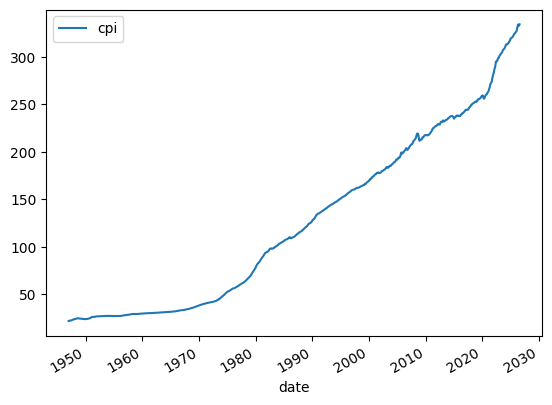

In [ ]:
cpi.plot()

### Interpretation Question 1

The CPI was about 21.5 in January 1947 and is now above 330. The base period is 1982-84 = 100.

**Q:** If the CPI is currently 314, what does that number mean in plain English? Write one sentence.

*Your answer here:*

A CPI of 314 means that the average price of goods and services today is about 3.14 times what it was in the 1982–84 base period.

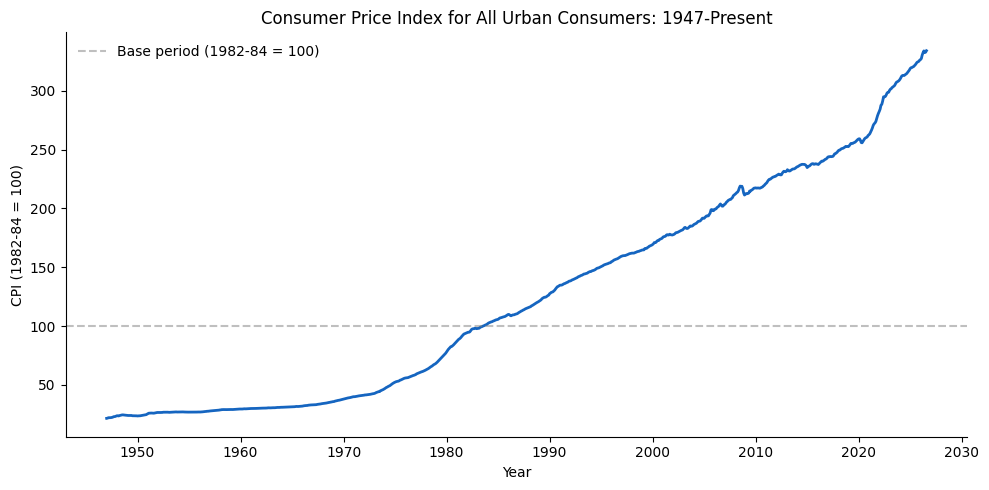

In [ ]:
# -----------------------------------------------------------
# Step 2: Plot the CPI level over time
# This chart shows the LEVEL — how high prices are.
# The vibecession hook: consumers live at levels, not rates.
# -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cpi.index, cpi["cpi"], color="#1565C0", linewidth=2)
ax.axhline(y=100, color="gray", linestyle="--", alpha=0.5,
           label="Base period (1982-84 = 100)")
ax.set_xlabel("Year")
ax.set_ylabel("CPI (1982-84 = 100)")
ax.set_title("Consumer Price Index for All Urban Consumers: 1947-Present")
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

## Part 2: Building `deflate_series()` (GUIDED — 15 min)

This is your first reusable function in the course. You will use it again in Chapters 4, 12, 16, and 20.

The deflation formula: **Real Value = (Nominal Value / CPI) × Base-Year CPI**

<!-- idiom-note -->
> ### New idiom — reading a function definition, and `lambda`
>
> The cell below hands you a **function**: `def` names it, the indented lines
> are its body, and `return` sends a value back to whoever called it. You are
> not asked to write one yet — Lab 4 does that. For now, read `def
> deflate_series(nominal, cpi, base_year=2020):` as *"to deflate a series you
> need a nominal series, a CPI, and optionally a base year, which is 2020
> unless you say otherwise."*
>
> You will also meet `lambda` in this lab: `df["x"].map(lambda v: v / 1000)`
> is a one-expression function with no name, handed to `.map()` so it can be
> run once per value. Part 0 above used one. If it needs a name, use `def`;
> `lambda` exists for exactly this hand-it-to-something-else case.


In [ ]:
def deflator(a,b):
  return a*(b/100)

In [ ]:
deflator(1,315)

3.15

In [ ]:
def add(a,b):
  """this add up stuff"""
  return a + b

In [ ]:
add(1,315)

316

In [ ]:
# -----------------------------------------------------------
# Step 3: Build the deflate_series() function
# WHY: We need to convert nominal dollars to constant dollars
# so we can compare purchasing power across time.
# -----------------------------------------------------------

def deflate_series(nominal, cpi, base_year=2020):
    """
    Convert a nominal time series to real (constant-dollar) values.

    Parameters
    ----------
    nominal : pd.Series
        Nominal values indexed by date.
    cpi : pd.Series
        CPI values indexed by date (same frequency as nominal).
    base_year : int
        The year whose dollars you want to express values in.

    Returns
    -------
    pd.Series
        Real values in base_year dollars.
    """
    # Get average CPI in the base year for rescaling
    base_cpi = cpi.loc[cpi.index.year == base_year].mean()

    # Align on shared dates — drop any NaN from mismatched ranges
    aligned = pd.DataFrame({"nominal": nominal, "cpi": cpi}).dropna()

    # Deflate: divide by CPI, multiply by base-year CPI
    real = (aligned["nominal"] / aligned["cpi"]) * base_cpi
    real.name = f"real_{base_year}"

    return real

print("deflate_series() defined!")

deflate_series() defined!


In [ ]:
# -----------------------------------------------------------
# Step 4: Quick test — deflate a single value
# Your grandfather earned $5,000 in 1970. What is that in 2020 dollars?
# -----------------------------------------------------------
cpi_1970 = cpi.loc[cpi.index.year == 1970, "cpi"].mean()
cpi_2020 = cpi.loc[cpi.index.year == 2020, "cpi"].mean()

real_value = (5000 / cpi_1970) * cpi_2020

print(f"CPI in 1970 (annual average): {cpi_1970:.1f}")
print(f"CPI in 2020 (annual average): {cpi_2020:.1f}")
print(f"$5,000 in 1970 = ${real_value:,.0f} in 2020 dollars")
# BOTH sides must be in the SAME dollars. $55,000 is a NOMINAL 2025 figure,
# so comparing it directly against a 2020-dollar number mixes two currencies
# and overstates the gain by roughly double.
cpi_2025 = cpi.loc[cpi.index.year == 2025, "cpi"].mean()
salary_today_in_2020_dollars = (55000 / cpi_2025) * cpi_2020

print(f"CPI in 2025 (annual average): {cpi_2025:.1f}")
print(f"$55,000 today = ${salary_today_in_2020_dollars:,.0f} in 2020 dollars")
print(f"\nComparing like with like, you are "
      f"{((salary_today_in_2020_dollars/real_value)-1)*100:.0f}% richer in real terms.")
print(f"Divide the nominal $55,000 by the 2020-dollar figure instead and you "
      f"get {((55000/real_value)-1)*100:.0f}% -- which is the units error this "
      f"whole chapter exists to prevent.")

CPI in 1970 (annual average): 38.8
CPI in 2020 (annual average): 258.9
$5,000 in 1970 = $33,322 in 2020 dollars
CPI in 2025 (annual average): 322.0
$55,000 today = $44,220 in 2020 dollars

Comparing like with like, you are 33% richer in real terms.
Divide the nominal $55,000 by the 2020-dollar figure instead and you get 65% -- which is the units error this whole chapter exists to prevent.


## Part 3: The Fifty-Year Wage Divergence (GUIDED — 10 min)

Now apply `deflate_series()` to nominal wages and see the divergence.

In [ ]:
# -----------------------------------------------------------
# Step 5: Pull nominal average hourly earnings from FRED
# FRED series: AHETPI (Average Hourly Earnings, Total Private)
# -----------------------------------------------------------
wages_nominal = load_fred("AHETPI", start="1964-01-01")
wages_nominal.name = "nominal_wage"

# Pull CPI for same period
cpi_wages = load_fred("CPIAUCSL", start="1964-01-01")
cpi_wages.name = "cpi"

# Deflate!
wages_real = deflate_series(wages_nominal, cpi_wages, base_year=2020)

print(f"Nominal wage range: ${wages_nominal.iloc[0]:.2f} to ${wages_nominal.iloc[-1]:.2f}")
print(f"Real wage range: ${wages_real.iloc[0]:.2f} to ${wages_real.iloc[-1]:.2f} (2020 $)")

Nominal wage range: $2.50 to $32.53
Real wage range: $20.92 to $25.20 (2020 $)


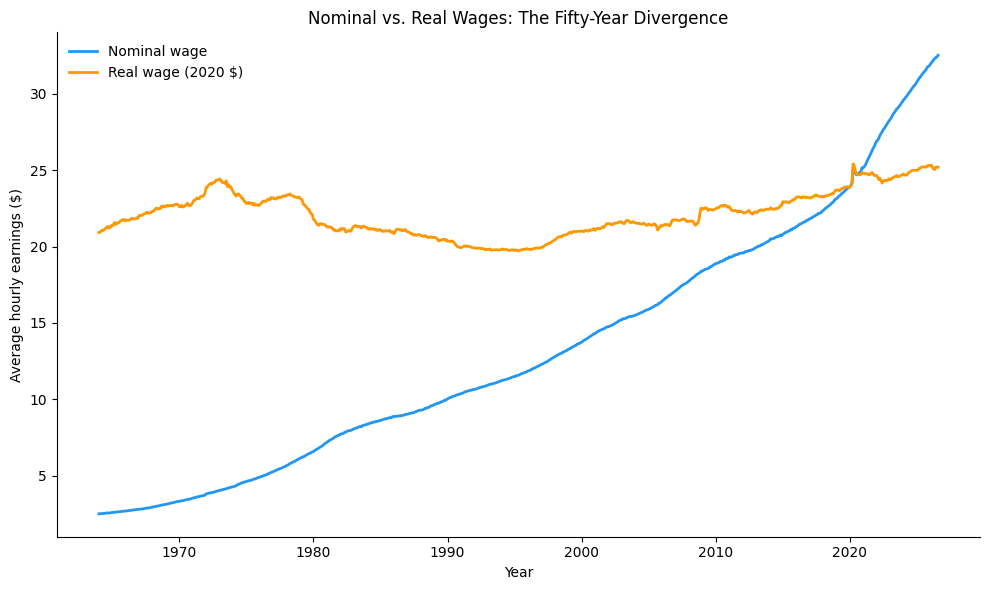

In [ ]:
# -----------------------------------------------------------
# Step 6: Plot the divergence — the key chart of the chapter
# -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(wages_nominal.index, wages_nominal,
        label="Nominal wage", color="#2196F3", linewidth=2)
ax.plot(wages_real.index, wages_real,
        label="Real wage (2020 $)", color="#FF9800", linewidth=2)
ax.set_xlabel("Year")
ax.set_ylabel("Average hourly earnings ($)")
ax.set_title("Nominal vs. Real Wages: The Fifty-Year Divergence")
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

### Interpretation Question 2

Look at the chart above.

**Q1:** In approximately what year did real wages peak? What happened economically around that time?

**Q2:** If you only looked at the nominal (blue) line, would you conclude that workers' purchasing power has been rising? Why is this misleading?

**Q3:** This chart is the "vibecession" in one picture. Explain in 2-3 sentences why consumers in 2023 felt worse off even though CPI inflation was falling.

*Your answers here:*
1. There are actually two peaks in real wages. The bigger one that actually matters is back in the early 1970s, when the 1973 oil shock happened. After that, real wages just kept sliding for like two decades. There's also a spot around 2020 that looks even higher, but that's misleading. It's mostly because many lower wage workers lost their jobs during the pandemic, so the average went up even though nobody actually got paid more.

2. If you only looked at the nominal line, you'd probably think workers have been getting richer over time, since the number keeps going up. But that's misleading because it only shows how many dollars people are making, not what those dollars can actually buy. Prices have also increased over time, so once you adjust for inflation using the real line, the increase in workers' purchasing power is much smaller.

3. People don't really notice the inflation rate itself, they notice how expensive things are. So even though inflation was going down in 2023, prices were still much higher than they were in 2019, they just weren't going up as quickly, so people still felt like everything was expensive.



## Part 4: Deflating the Big Mac (YOUR TURN — 10 min)

Now apply what you have learned. Load the Big Mac data from Lab 1 and deflate US
prices to see how much of the price increase is "real" and how much is inflation.

Three blanks in the next cell. Each one takes a single expression.

In [ ]:
# -----------------------------------------------------------
# Step 7: Load Big Mac data (same URL from Ch 1)
# -----------------------------------------------------------
url = "https://raw.githubusercontent.com/TheEconomist/big-mac-data/master/output-data/big-mac-full-index.csv"
bigmac = pd.read_csv(url, parse_dates=["date"])

# Filter to United States only
us = bigmac[bigmac["name"] == "United States"][["date", "dollar_price"]].copy()
us = us.set_index("date").sort_index()
us.columns = ["bigmac_nominal"]

print(f"US Big Mac observations: {len(us)}")
print(f"Date range: {us.index.min().date()} to {us.index.max().date()}")
print(f"Price range: ${us['bigmac_nominal'].min():.2f} to ${us['bigmac_nominal'].max():.2f}")

US Big Mac observations: 45
Date range: 2000-04-01 to 2026-07-01
Price range: $2.24 to $6.22


In [ ]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 8: Deflate Big Mac prices to 2020 dollars
# -----------------------------------------------------------

# Step A (done for you): pull CPI from 2000 onward. No API key needed.
cpi_bm = load_fred("CPIAUCSL", start="2000-01-01")

# Step B (done for you): the Big Mac index is semi-annual and the CPI is
# monthly, so for each Big Mac date we take the most recent CPI reading at or
# before it. .asof() is what does that.
us["cpi"] = us.index.map(lambda d: cpi_bm.asof(d))

# Step C: the base-year CPI. Average every 2020 observation of cpi_bm.
#   Hint: this is the same one-liner Step 4 used, with cpi_bm in place of cpi.
base_cpi = cpi_bm.loc[cpi_bm.index.year == 2020].mean()

# Step D: deflate.  Real = (Nominal / CPI) * Base CPI
#   Hint: the nominal column is us["bigmac_nominal"] and the CPI column is
#   us["cpi"]. Whole columns divide element by element — no loop.
bigmac_real = (us["bigmac_nominal"] / us["cpi"]) * base_cpi

us["bigmac_real"] = bigmac_real          # done for you

# Step E: the percentage change from the first observation to the last, for
#   each series. .iloc[-1] is the last row, .iloc[0] the first.
nominal_change = ((us["bigmac_nominal"].iloc[-1] / us["bigmac_nominal"].iloc[0]) - 1) * 100
real_change = ((us["bigmac_real"].iloc[-1] / us["bigmac_real"].iloc[0]) - 1) * 100

print(f"Nominal change: {nominal_change:.0f}%")
print(f"Real change: {real_change:.0f}%")
cpi_change = ((us["cpi"].iloc[-1] / us["cpi"].iloc[0]) - 1) * 100   # done for you
print(f"CPI change over the same dates: {cpi_change:.0f}%")

Nominal change: 178%
Real change: 43%
CPI change over the same dates: 95%


In [ ]:
# -----------------------------------------------------------
# CHECK — Run as-is after Step 8
# -----------------------------------------------------------
# 1. Units. A price in 2020 dollars, observed in 2020, is a 2020 price, so
#    real and nominal must agree in 2020 (to within a couple of percent: the
#    Big Mac dates use one month's CPI, the base uses the whole year).
in_2020 = us[us.index.year == 2020]
ratio = (in_2020["bigmac_real"] / in_2020["bigmac_nominal"]).mean()
assert 0.97 < ratio < 1.03, (
    f"In 2020 your real price is {ratio:.3f} times the nominal price; it should be "
    "about 1. A result near 0.004 means Base CPI is missing; near 0.39, the base is "
    "100 instead of the 2020 CPI.")

# 2. Base year. base_cpi should be the 2020 average, not one month.
cpi_2020 = cpi_bm[cpi_bm.index.year == 2020]
assert cpi_2020.min() <= base_cpi <= cpi_2020.max(), (
    f"base_cpi = {base_cpi:.2f} is not a 2020 CPI level.")
assert not (cpi_2020 == base_cpi).any(), (
    "base_cpi equals a single month's CPI; Step C asks for the 2020 average.")

# 3. The growth identity: (1 + nominal) = (1 + real) x (1 + CPI).
assert abs((1 + nominal_change / 100) - (1 + real_change / 100) * (1 + cpi_change / 100)) < 0.01, (
    "real_change is inconsistent with nominal_change and the CPI: "
    "(1 + nominal) should equal (1 + real) x (1 + CPI).")
print("Step 8 check passed: real prices are in 2020 dollars.")
print(f"  (1 + {nominal_change:.0f}%) = (1 + {real_change:.0f}%) x (1 + {cpi_change:.0f}%)")
print(f"  Subtracting instead: {nominal_change:.0f}% - {real_change:.0f}% = "
      f"{nominal_change - real_change:.0f} points, which is not the CPI's {cpi_change:.0f}%.")

Step 8 check passed: real prices are in 2020 dollars.
  (1 + 178%) = (1 + 43%) x (1 + 95%)
  Subtracting instead: 178% - 43% = 135 points, which is not the CPI's 95%.


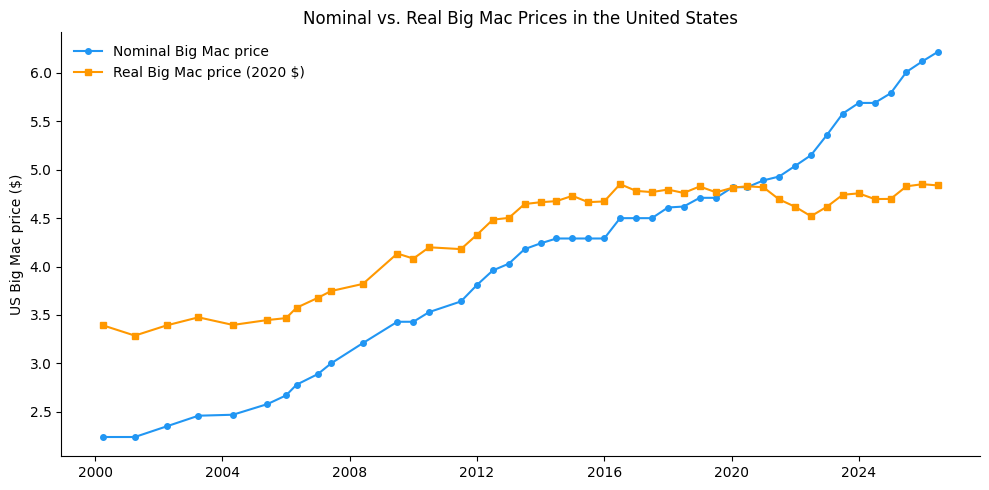

In [ ]:
# -----------------------------------------------------------
# GUIDED — Run as-is (it needs Step 8 above to be filled in first)
# Step 9: Plot nominal vs. real Big Mac prices
# This is the wage divergence chart from Step 6, pointed at a burger.
# -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(us.index, us["bigmac_nominal"], marker="o", markersize=4,
        label="Nominal Big Mac price", color="#2196F3", linewidth=1.5)
ax.plot(us.index, us["bigmac_real"], marker="s", markersize=4,
        label="Real Big Mac price (2020 $)", color="#FF9800", linewidth=1.5)

ax.set_ylabel("US Big Mac price ($)")
ax.set_title("Nominal vs. Real Big Mac Prices in the United States")
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

# YOUR TASK: markers are used here (marker="o", marker="s") because the
# series is semi-annual — one point every six months, a few dozen in all. Change both
# markers to "" (no marker) and re-run. Write one sentence on which version
# is more honest about how much data actually exists.

### Interpretation Question 3

**Q1:** Your check printed three growth rates: nominal, real, and the CPI. Why is
*nominal minus real* not equal to the CPI's growth? Use the identity the check
printed, and say which of the three numbers is "inflation".

**Q2:** In Chapter 1, you compared Big Mac prices *across countries* (PPP). In this lab, you compared Big Mac prices *across time* (deflation). Both are index operations. What is the key difference between them?

**Q3:** A CEO tells shareholders: "Our revenue grew 15% this year." Inflation was 5%. What question should you ask, and what is the real growth rate?

*Your answers here:*

1. The check uses (1 + nominal) = (1 + real) × (1 + CPI), and since that's multiplication, you can't just subtract two percentages and get the third one. For example, nominal was 178% and real was 43%, so 178 - 43 = 135%, but the actual CPI change was 95% because real growth and CPI growth compound together instead of just adding up. Out of the three numbers, the CPI growth is basically the one that represents inflation.

2. Both are basically the same kind of index comparison, just in different directions. PPP keeps the burger and time period the same and compares prices across countries, while deflation keeps the burger and country the same and compares prices across different years. So PPP is comparing across space, while deflation is comparing across time.

3. The question I should ask is whether that 15% is nominal or real. If inflation was 5%, the real growth rate isn't just 15 - 5 = 10%, since these compound instead of just subtracting. It's actually (1.15 / 1.05 - 1) × 100, which is about 9.5%, so some of the revenue growth was really just from inflation.



---

## Part 5 (Optional — 10 min): The same data through the FRED API

Everything above used FRED's CSV endpoint, which needs no credential. Production
code usually uses the API instead, because it can search the catalogue, pull
metadata, and handle revisions — none of which a CSV URL can do. That route needs
the API key you set up at the top of this notebook.

**If you did not get a key, skip this part.** Nothing later depends on it.

The first cell below is a **guard**. It checks that you actually replaced the
placeholder before any request is made, and stops with a plain-English message if
you did not. Without a guard, the placeholder sails through, the setup cell prints
"Setup complete!", and the failure surfaces four cells later as thirty lines of
urllib traceback ending in `ValueError: Bad Request. The value for variable api_key
is not registered` — which tells you nothing about what to do.

In [20]:
from google.colab import userdata
userdata.get('FRED_API_KEY')

'77f74423aa27d570147b7103a927b744'

In [25]:
# skip-run — needs your own FRED API key; the rest of the lab does not.
# -----------------------------------------------------------
# OPTIONAL — Part 5, cell 1: the guard
# -----------------------------------------------------------

FRED_API_KEY = userdata.get('FRED_API_KEY')   # <-- paste your key BETWEEN the quotes

if FRED_API_KEY.strip().upper() in {"YOUR_API_KEY_HERE", ""} or len(FRED_API_KEY) < 20:
    raise ValueError(
        "\n"
        "\n  No FRED API key found in this cell."
        "\n"
        "\n  You are still holding the placeholder. Nothing is broken and you have"
        "\n  not done anything wrong -- this cell simply has no key to send yet."
        "\n"
        "\n  To fix it:"
        "\n    1. Get a free key: https://fredaccount.stlouisfed.org/apikeys"
        "\n       (create an account, confirm the email, click Request API Key)"
        "\n    2. Copy the 32-character key FRED shows you."
        "\n    3. Come back to this cell and replace the words YOUR_API_KEY_HERE"
        "\n       with your key, leaving the quotation marks in place."
        "\n    4. Re-run this cell."
        "\n"
        "\n  Or skip Part 5 entirely. Parts 1-4 need no key and are the graded"
        "\n  content of this lab."
        "\n"
    )

print(f"Key accepted ({len(FRED_API_KEY)} characters). Ready for the API route.")

Key accepted (32 characters). Ready for the API route.


In [26]:
# skip-run — needs your own FRED API key.
# -----------------------------------------------------------
# OPTIONAL — Part 5, cell 2: the same CPI series, via fredapi
# -----------------------------------------------------------
# The ! line below is a shell command, not Python: it installs the fredapi
# package onto this Colab machine. Run it once per session.
!pip install fredapi -q

from fredapi import Fred

fred = Fred(api_key=FRED_API_KEY)
cpi_api = fred.get_series("CPIAUCSL", observation_start="1947-01-01")

print(f"Via the API:  {len(cpi_api)} observations, latest {cpi_api.iloc[-1]:.1f}")
print(f"Via the CSV:  {len(cpi):,} observations, latest {cpi['cpi'].iloc[-1]:.1f}")
print()
print("Same numbers, two doors. The API can also do what a CSV URL cannot:")
print(fred.search("unemployment rate", limit=3)[["title", "frequency"]].to_string())

Via the API:  956 observations, latest 334.1
Via the CSV:  955 observations, latest 334.1

Same numbers, two doors. The API can also do what a CSV URL cannot:
                                                     title frequency
series id                                                           
UNRATE                                   Unemployment Rate   Monthly
UNRATENSA                                Unemployment Rate   Monthly
LNS14000006  Unemployment Rate - Black or African American   Monthly


<Axes: >

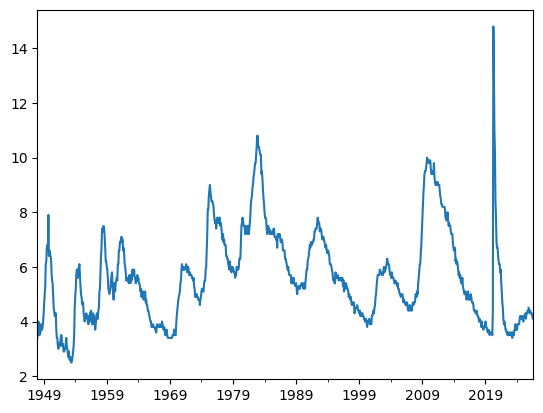

In [27]:
unemp = fred.get_series("UNRATE", observation_start="1948-01-01")
unemp.plot()

### Interpretation Question 4

**Q1:** Parts 1-4 pulled the same CPI series with no credential at all. Why does
FRED bother issuing API keys, if the data is free either way?

**Q2:** You are about to push this notebook to a public GitHub repository. What
should be sitting in the `FRED_API_KEY` line when you do, and what happens if your
real key is there instead?

*Your answers here:*

1. Even though the data itself is free, FRED still needs a way to know who's making requests to their servers. The API key helps them track requests, manage traffic, and limit access if someone is using the API too much or abusing it. So the key isn't really about whether the data is free; it's more about managing API access.
2. Before pushing the notebook, that line should still have the placeholder, “YOUR_API_KEY_HERE,” instead of your actual key. If your real key is in a public GitHub repository, anyone could copy it and use it, which could use up your request limit or get the key flagged or revoked.

---
## AI-Assisted Expansion: Interactive Deflation Explorer

**The Generative AI Policy: Foundations First, Expansion Second.** You have now established manual mastery over pulling CPI from FRED, deflating nominal series, and reading real vs. nominal charts. You are now authorized to operate under the "Co-Pilot Rule."

### Your Expansion Task
Build an interactive explorer (ipywidgets + matplotlib, running inside Colab) that lets the user:
1. Choose a series — average hourly earnings or the US Big Mac price
2. Move a base-year slider and watch the real series relabel into that year's dollars
3. Toggle between nominal and real
4. Read the growth rate over the chosen window, which should NOT change with the base year

### P.R.I.M.E. Prompt
Copy and paste this into Claude or ChatGPT:

In [ ]:
# -----------------------------------------------------------
# 🤖 AI EXPANSION — Co-Pilot required
# Copy the P.R.I.M.E. prompt above into Claude, then paste
# the generated code here. Run it and verify.
# -----------------------------------------------------------

# [Prep] Act as an expert Python data scientist who teaches
# introductory economics with interactive notebooks.
#
# [Request] I just finished a lab where I pulled CPI from FRED
# with a load_fred() helper, deflated nominal wages with
# deflate_series(nominal, cpi, base_year), and deflated US Big
# Mac prices to 2020 dollars. Build an interactive explorer that
# runs inside Google Colab:
#   1. a dropdown to pick average hourly earnings
#      (wages_nominal, deflated with cpi_wages) or the
#      US Big Mac price (us["bigmac_nominal"])
#   2. a base-year slider (2000-2025) that re-deflates the series
#   3. a nominal / real toggle
#   4. a text readout of the percentage change from the first to
#      the last observation, in both nominal and real terms
#
# [Iterate] Use ipywidgets and matplotlib only. Reuse my
# variables and functions: load_fred, deflate_series, cpi_bm,
# cpi_wages, wages_nominal, wages_real, us. Do not use deprecated pandas functions.
#
# [Mechanism Check] Add inline comments explaining:
#   - why moving the base year changes the dollar LEVEL of the
#     real series but not its growth rate
#   - why the Big Mac series needs .asof() to line up with the
#     monthly CPI
#   - how the widget callback redraws the chart
#
# [Evaluate] Explain what the explorer shows about the claim
# "real wages have been flat for fifty years".

# PASTE AI-GENERATED CODE BELOW:

In [33]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd

# ---------------------------------------------------------------------------
# Widgets
# ---------------------------------------------------------------------------
series_dropdown = widgets.Dropdown(
    options=[('Average Hourly Earnings', 'wages'), ('US Big Mac Price', 'bigmac')],
    value='wages',
    description='Series:',
    style={'description_width': 'initial'}
)

base_year_slider = widgets.IntSlider(
    value=2020, min=2000, max=2025, step=1,
    description='Base year:', continuous_update=False,
    style={'description_width': 'initial'}
)

type_toggle = widgets.ToggleButtons(
    options=[('Nominal', 'nominal'), ('Real', 'real')],
    value='real',
    description='Type:'
)

readout = widgets.HTML()
out = widgets.Output()

# ---------------------------------------------------------------------------
# Helper: build the series to plot given the current widget state
# ---------------------------------------------------------------------------
def get_nominal_and_cpi(series_choice):
    """Return (nominal_series, cpi_series) already aligned to the same index."""
    if series_choice == 'wages':
        nominal = wages_nominal
        cpi = cpi_wages  # monthly CPI, already on the same monthly index as wages
        return nominal, cpi

    # --- Big Mac branch --------------------------------------------------
    nominal = us['bigmac_nominal']

    # WHY .asof(): the Big Mac series is only observed a couple times a
    # year (roughly Jan/Jul), while cpi_bm is monthly. deflate_series()
    # needs one CPI value per Big Mac observation date. .asof() looks
    # up, for each Big Mac date, the most recent CPI print at or before
    # that date -- effectively forward-filling CPI onto the sparse Big
    # Mac calendar. A plain .reindex() would return NaN for dates that
    # don't exist in cpi_bm's index, and interpolating would fabricate
    # CPI values between actual BLS releases.
    aligned_cpi = cpi_bm.asof(nominal.index)

    return nominal, aligned_cpi




def pct_change_first_last(s):
    s = s.dropna()
    if len(s) < 2:
        return float('nan')
    return (s.iloc[-1] / s.iloc[0] - 1) * 100


# ---------------------------------------------------------------------------
# Redraw callback
# ---------------------------------------------------------------------------
def redraw(change=None):
    # WHY this runs on every widget change: each widget's .observe()
    # call below registers `redraw` as the handler for its 'value'
    # trait. Whenever the user moves the slider, flips the toggle, or
    # picks a new series, ipywidgets fires a change event, Python calls
    # redraw(), and we rebuild the series + figure from scratch inside
    # the Output widget. clear_output(wait=True) erases the previous
    # plot right before the new one is drawn, so the chart updates in
    # place instead of stacking multiple plots.
    series_choice = series_dropdown.value
    base_year = base_year_slider.value
    series_type = type_toggle.value

    nominal, cpi = get_nominal_and_cpi(series_choice)
    nominal_change = pct_change_first_last(nominal)

    real = deflate_series(nominal, cpi, base_year)
    real_change = pct_change_first_last(real)

    plotted = nominal if series_type == 'nominal' else real
    label = 'Nominal' if series_type == 'nominal' else f'Real (base {base_year})'
    title_name = 'Average Hourly Earnings' if series_choice == 'wages' else 'US Big Mac Price'

    with out:
        out.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(9, 5))
        ax.plot(plotted.index, plotted.values, linewidth=2)
        ax.set_title(f'{title_name} -- {label}')
        ax.set_xlabel('Date')
        ax.set_ylabel('Dollars')
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    readout.value = (
        f"<b>% change, first to last observation:</b><br>"
        f"Nominal: {nominal_change:.1f}%<br>"
        f"Real (base {base_year}): {real_change:.1f}%"
    )


# ---------------------------------------------------------------------------
# Wire up observers and display
# ---------------------------------------------------------------------------
series_dropdown.observe(redraw, names='value')
base_year_slider.observe(redraw, names='value')
type_toggle.observe(redraw, names='value')

controls = widgets.VBox([series_dropdown, base_year_slider, type_toggle, readout])
display(widgets.HBox([controls, out]))
redraw()  # initial draw

### Document the interaction

Three short answers. This is what is graded for the expansion, not the code.

1. **What did the AI get wrong or leave out?** Name one line you had to change,
   or one claim in its explanation that your own output contradicts.
2. **How did you verify it?** Point to a number the dashboard shows that you
   also computed by hand earlier in this lab, and say whether they match.
3. **What would you ask differently next time?**

*Your answers here:*

1. The AI made a build_series() function with a lot of comments explaining the deflation, but it actually never uses the function. Instead, redraw() does the same calculation again. I noticed this when I followed the code to see where the values in the dashboard were coming from.
2. I set the dashboard to Big Mac, Real, and a base year of 2020, and it showed a real change of about 43%. This matches the real change I calculated by hand in Part 4, Step 8, so I know the calculation in redraw() is working correctly.
3. Next time, I would ask the AI to make sure that every function it creates is actually used in the code. That way, I wouldn't have to go through the code myself to find unused or repeated parts.

## Part 6: Write your README

Your README is what a reader sees before they open a single cell. Draft it with
the README prompt in the Digital Portfolio section below, then check every
number in the draft against your own output.

---
## Digital Portfolio: Institutional Signaling

### Generate Your Professional README
Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.** Replace every `[YOUR VALUE]` with the number from your own output before you paste it.

In [34]:
# -----------------------------------------------------------
# 🤖 AI EXPANSION — README generation (no code, just docs)
# -----------------------------------------------------------

# PASTE THIS PROMPT INTO CLAUDE:
#
# "I need help writing a project description for my data science lab.
# **Important Rule:** Do NOT generate any Python code for me.

# **What I did in this lab:**
# * Pulled CPI and average hourly earnings from FRED with no API key
# * Wrote deflate_series() and converted wages to constant 2020 dollars
# * Showed nominal hourly earnings rose from $2.50 to $32.53
#   while real earnings moved from $20.92 to $25.20
# * Deflated the US Big Mac price: nominal +178%, real
#   +43%, CPI +95% over the same dates
# * Built an interactive deflation explorer with a base-year slider

# **Please write a README.md entry including:**
# 1. Project Title: Deflating Economic Data — Nominal vs. Real
# 2. Objective: A professional one-sentence summary
# 3. Methodology: Bullet points of technical steps
# 4. Key Findings: Summary of results
# Make this sound like a professional tech economist wrote it."

---

## Submit this lab on GitHub

**Repository name for this lab:** `econ3916-lab02-deflation`

**First time?** Read the **GitHub Setup** page in the Start Here module once,
start to finish. It assumes you have never used git and never seen GitHub.

1. On [github.com](https://github.com): **+** (top right) → **New repository**.
   Name it exactly `econ3916-lab02-deflation`, tick **Add a README file**, and create it.
2. In Colab: **File → Save a copy in GitHub**. Choose `econ3916-lab02-deflation`, branch `main`,
   commit message `Lab 02 submission`. This pushes the notebook, and the
   notebook's rendered output — charts included — is what is graded.
3. Open the repo on github.com, click `README.md`, then the pencil icon, and
   paste in the README you drafted from the README prompt above. **Commit
   changes.** Check every number in it against your own output first: this
   goes out under your name.
4. On Canvas: in Colab use **File → Download → Download .ipynb**, upload that
   file to the assignment, and paste your repository URL in the **Comments**
   box beside the upload. Then click **Submit**. Do not use the Website URL
   tab: Canvas keeps one submission, so a URL sent on its own replaces your
   notebook.

No terminal, no token, nothing to install.

---

**Lab 2 complete!** You now have a reusable `deflate_series()` function that you will use throughout this course. Remember: never compare monetary values across time without deflating first.